In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc_context
import scanpy as sc
from skimage.filters import threshold_otsu, threshold_triangle
from sklearn.neighbors import kneighbors_graph
from sklearn.neighbors import NearestNeighbors
from scipy.sparse.csgraph import connected_components

import os
from joblib import Parallel, delayed
import pickle

# Load data

In [77]:
data = pd.read_csv(r'..\coculture2\00_analysis\expression.csv')

In [78]:
data.drop(columns=['label.1'], inplace=True)

In [79]:
cxcl14_thre = threshold_otsu(data['CXCL14'].to_numpy()) * 0.5
col1a1_thre = threshold_otsu(data['COL1A1'].to_numpy()) * 0.5

In [101]:
data['CXCL14+'] = data['CXCL14'].tolist() > cxcl14_thre
data['COL1A1+'] = data['COL1A1'].tolist() > np.float64(5)

In [102]:
data

,label,area,row,col,eccentricity,CXCL14,COL1A1,CXCL14+,COL1A1+
0,2,323,155.300310,23246.863777,0.699151,1.0,0.0,False,False
1,5,403,192.307692,23226.372208,0.682432,1.0,0.0,False,False
2,7,484,218.681818,23216.154959,0.441205,1.0,0.0,False,False
3,9,235,254.651064,23207.293617,0.872737,1.0,0.0,False,False
4,11,1019,290.620216,23196.612365,0.803435,2.0,0.0,False,False
...,...,...,...,...,...,...,...,...,...
8573,10425,6082,23842.973200,20407.038310,0.835911,9.0,44.0,False,True
8574,10428,7325,23860.562594,19654.737611,0.760318,8.0,31.0,False,True
8575,10444,4954,23914.478401,21093.942874,0.717850,5.0,11.0,False,True
8576,10445,7137,23929.472327,20408.105927,0.737973,10.0,36.0,False,True


# kNN graph among cells

In [103]:
k=5

In [104]:
data.head()

,label,area,row,col,eccentricity,CXCL14,COL1A1,CXCL14+,COL1A1+
0,2,323,155.300310,23246.863777,0.699151,1.0,0.0,False,False
1,5,403,192.307692,23226.372208,0.682432,1.0,0.0,False,False
2,7,484,218.681818,23216.154959,0.441205,1.0,0.0,False,False
3,9,235,254.651064,23207.293617,0.872737,1.0,0.0,False,False
4,11,1019,290.620216,23196.612365,0.803435,2.0,0.0,False,False


In [105]:
adj_matrix = kneighbors_graph(data[['row','col']].values.astype('float'), n_neighbors=k, mode='connectivity', include_self=False)

adj_matrix = adj_matrix.maximum(adj_matrix.T)

row,col = adj_matrix.nonzero()
edges = np.column_stack((row,col))
unique_edges = edges[edges[:, 0] < edges[:, 1]]

In [106]:
with open(r'..\coculture2\00_analysis\unique_edges.pkl', 'wb') as f:
    pickle.dump(unique_edges, f)

## count edges between col1a1+ and col1a1-, cxcl14+ cells

In [93]:
def count_edges(df, edges):

    edges = np.asarray(edges)

    i = edges[:, 0]
    j = edges[:, 1]

    col3_i = df.loc[i, 'CXCL14+'].values
    col3_j = df.loc[j, 'CXCL14+'].values

    col4_i = df.loc[i, 'COL1A1+'].values
    col4_j = df.loc[j, 'COL1A1+'].values

    mask = (
        (col3_i & (~col3_j) & col4_j) |
        (col3_j & (~col3_i) & col4_i)
    )

    return np.sum(mask)

In [94]:
edges = count_edges(data, unique_edges)

In [95]:
edges

np.int64(23)

In [96]:
permutated_count = []
for n in range(1000):
    rng = np.random.default_rng()
    shuffled_df = data.sample(frac=1, replace=False, random_state=rng.integers(1e9)).reset_index(drop=True)
    permutated_count.append(count_edges(shuffled_df, unique_edges))

In [97]:
np.sum(permutated_count > edges)

np.int64(118)

In [98]:
p = np.sum(permutated_count > edges) / 100

In [99]:
z = (edges - np.mean(permutated_count)) / np.std(permutated_count)

In [100]:
z

np.float64(1.032399433245233)

## permutation of stromal and cxcl14+ immune in xenium

In [42]:
from tqdm import tqdm

In [43]:
annotation_dir = r'Y:\coskun-lab\Zhou\12_MSG\nanostring_xenium_comp\results\graph_classification_v5\xenium'
fns = ['xenium_83a', 'xenium_83b',
       'xenium_84a', 'xenium_84b',
       'xenium_174c', 'xenium_174d',
       'xenium_7202c', 'xenium_7202d']

annotations_tissue = {}
for fn in tqdm(fns):
    df = pd.read_csv(os.path.join(annotation_dir, f'{fn}_spatial_annotation_filtered.csv'))
    df.index = df['cell_id'].tolist()
    annotations_tissue[fn.split('_')[-1]] = df

100%|██████████| 8/8 [00:01<00:00,  5.85it/s]


In [44]:
exp_tissue = {}
annotation_dir = r'Y:\coskun-lab\Zhou\12_MSG\nanostring_xenium_comp\results\cell_type_annotation\v4'
for fn in tqdm(fns):
    adata = sc.read_h5ad(os.path.join(annotation_dir, 'adata_'+fn.split('_')[-1]+'.h5ad'))
    df = pd.DataFrame(adata.raw.X, index=adata.obs_names, columns=adata.var_names)
    exp_tissue[fn.split('_')[-1]] = df

100%|██████████| 8/8 [00:35<00:00,  4.42s/it]


In [51]:
edges_tissue = {}
graph_dir = r'Y:\coskun-lab\Zhou\12_MSG\nanostring_xenium_comp\results\graph_classification_v5\xenium'
for fn in tqdm(fns):
    edges = pd.read_pickle(os.path.join(graph_dir, fn+'_spatial_annotation_filtered_edges.pkl'))
    edges_tissue[fn.split('_')[-1]] = edges

100%|██████████| 8/8 [00:00<00:00, 14.33it/s]


In [63]:
immune_cells = ['Plasma cell', 'CD4 T-cell', 'CD8 T-cell', 'Macrophage', 'B-cell', 'Mast cell']

In [101]:
def count_edges_xenium(annotation, edges):
    

    node1 = annotation.iloc[edges[:,0]]
    node2 = annotation.iloc[edges[:,1]]

    return np.sum((((node1['cell_types']=='Stromal').values & (node2['cell_types'].isin(immune_cells)).values & node2['CXCL14+'].values) | 
            ((node1['cell_types'].isin(immune_cells)).values & node1['CXCL14+'].values & (node2['cell_types']=='Stromal').values)))

In [102]:
count_tissue = {}
for tissue in fns:
    tissue = tissue.split('_')[-1]
    annotation = annotations_tissue[tissue]
    expr = exp_tissue[tissue]
    edges = edges_tissue[tissue]
    cxcl14_exp = expr.loc[annotation.index]['CXCL14'].to_numpy()
    cxcl14_thre = threshold_otsu(cxcl14_exp)
    annotation['CXCL14+'] = cxcl14_exp > cxcl14_thre
    count_tissue[tissue] = count_edges_xenium(annotation, edges)

In [82]:
count_tissue

{'83a': np.int64(2703),
 '83b': np.int64(2772),
 '84a': np.int64(5800),
 '84b': np.int64(6435),
 '174c': np.int64(1152),
 '174d': np.int64(1138),
 '7202c': np.int64(2379),
 '7202d': np.int64(2365)}

In [103]:
count_tissue_shuffle = {}
for k in count_tissue.keys():
    count_tissue_shuffle[k] = []

for k in count_tissue.keys():
    annotation = annotations_tissue[k]
    expr = exp_tissue[k]
    edges = edges_tissue[k]
    for i in range(1000):
        rng = np.random.default_rng()
        shuffled_df = annotation.sample(frac=1, replace=False, random_state=rng.integers(1e9)).reset_index(drop=True)
        count_tissue_shuffle[k].append(count_edges_xenium(shuffled_df, edges))

In [106]:
temp = np.array(list(count_tissue_shuffle.values()))

In [111]:
count = np.sum(list(count_tissue.values()))
permutated_count = np.sum(temp, axis=0)

In [113]:
z_xenium = (count - np.mean(permutated_count)) / np.std(permutated_count)
z_xenium

np.float64(38.86164890525405)

In [116]:
count

np.int64(24744)

In [115]:
p = np.sum(permutated_count > count) / 1000
p

np.float64(0.0)

## permutation of stromal and cxcl14+ immune in merfish

In [141]:
annotation_dir = r'Y:\coskun-lab\Zhou\12_MSG\MERSCOPE\20251229_msg-1_140gene\results'
fns = ['R1_7289', 'R2_7295', 'R3_7320', 'R8_159', 'R9_163']

annotations_tissue = {}
for fn in tqdm(fns):
    df = pd.read_csv(os.path.join(annotation_dir, f'202512291513_20251230msg1p140_VMSC11512_region_{fn}_annotated_filtered.csv'))
    df.index = df['cell'].astype(str).tolist()
    annotations_tissue[fn] = df

exp_tissue = {}
for fn in tqdm(fns):
    adata = sc.read_h5ad(os.path.join(annotation_dir, f'202512291513_20251230msg1p140_VMSC11512_region_{fn}_annotated.h5ad'))
    df = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
    exp_tissue[fn] = df

edges_tissue = {}
graph_dir = r'Y:\coskun-lab\Zhou\12_MSG\MERSCOPE\20251229_msg-1_140gene\results\stromal_neighborhoods'
for fn in tqdm(fns):
    edges = pd.read_pickle(os.path.join(graph_dir, '202512291513_20251230msg1p140_VMSC11512_region_'+fn+'_annotated_filtered_edges.pkl'))
    edges_tissue[fn] = edges

100%|██████████| 5/5 [00:00<00:00, 118.85it/s]


In [144]:
annotations_tissue['R1_7289']['cell_type'].unique()

array(['Myoepithelial', 'Acini', 'Stromal', 'Endothelial cell', 'B-cell',
       'Macrophage', 'Ductal Epithelial', 'T-cell', 'Dendritic cell',
       'Pericytes', 'Mast cell'], dtype=object)

In [145]:
immune_cells = ['B-cell', 'Macrophage', 'T-cell', 'Dendritic cell', 'Mask cell']

In [146]:
def count_edges_merfish(annotation, edges):
    
    node1 = annotation.iloc[edges[:,0]]
    node2 = annotation.iloc[edges[:,1]]

    return np.sum((((node1['cell_type']=='Stromal').values & (node2['cell_type'].isin(immune_cells)).values & node2['CXCL14+'].values) | 
            ((node1['cell_type'].isin(immune_cells)).values & node1['CXCL14+'].values & (node2['cell_type']=='Stromal').values)))

In [147]:
count_tissue = {}
for tissue in fns:
    annotation = annotations_tissue[tissue]
    expr = exp_tissue[tissue]
    edges = edges_tissue[tissue]
    cxcl14_exp = expr.loc[annotation.index]['CXCL14'].to_numpy()
    cxcl14_thre = threshold_otsu(cxcl14_exp)
    annotation['CXCL14+'] = cxcl14_exp > cxcl14_thre
    count_tissue[tissue] = count_edges_merfish(annotation, edges)

In [148]:
count_tissue

{'R1_7289': np.int64(2401),
 'R2_7295': np.int64(1821),
 'R3_7320': np.int64(1096),
 'R8_159': np.int64(145),
 'R9_163': np.int64(556)}

In [149]:
count_tissue_shuffle = {}
for k in count_tissue.keys():
    count_tissue_shuffle[k] = []

for k in count_tissue.keys():
    annotation = annotations_tissue[k]
    expr = exp_tissue[k]
    edges = edges_tissue[k]
    for i in range(1000):
        rng = np.random.default_rng()
        shuffled_df = annotation.sample(frac=1, replace=False, random_state=rng.integers(1e9)).reset_index(drop=True)
        count_tissue_shuffle[k].append(count_edges_merfish(shuffled_df, edges))

In [150]:
temp = np.array(list(count_tissue_shuffle.values()))

In [151]:
count = np.sum(list(count_tissue.values()))
permutated_count = np.sum(temp, axis=0)

In [152]:
z_merfish = (count - np.mean(permutated_count)) / np.std(permutated_count)
z_merfish

np.float64(23.89331407494345)

In [153]:
count

np.int64(6019)

In [154]:
p = np.sum(permutated_count > count) / 1000
p

np.float64(0.0)

# CXCL14+ stromal enrichmeent around immune cells

## coculture

In [8]:
data = pd.read_csv(r'..\coculture1\00_analysis\expression.csv')

In [231]:
data.drop(columns=['label.1'], inplace=True)

In [207]:
cxcl14_thre = threshold_otsu(data['CXCL14'].to_numpy()) * 0.5
col1a1_thre = threshold_otsu(data['COL1A1'].to_numpy()) * 0.5

In [214]:
col1a1_thre

np.float64(31.7255859375)

In [232]:
data['CXCL14+'] = data['CXCL14'].tolist() > np.float64(10)
data['COL1A1+'] = data['COL1A1'].tolist() > np.float64(5)

In [233]:
data['COL1A1+'].value_counts()

COL1A1+
False    3070
True     2933
Name: count, dtype: int64

In [234]:
data['CXCL14+'].value_counts()

CXCL14+
False    3561
True     2442
Name: count, dtype: int64

In [235]:
def count_edges(df, edges):

    edges = np.asarray(edges)

    i = edges[:, 0]
    j = edges[:, 1]

    col3_i = df.loc[i, 'CXCL14+'].values
    col3_j = df.loc[j, 'CXCL14+'].values

    col4_i = df.loc[i, 'COL1A1+'].values
    col4_j = df.loc[j, 'COL1A1+'].values

    mask = (
        (col3_i & col4_i & (~col4_j)) |
        ((~col4_i) & col3_j & col4_j)
    )

    return np.sum(mask)

In [236]:
edges = count_edges(data, unique_edges)

In [237]:
edges

np.int64(5408)

In [238]:
permutated_count = []
for n in range(100):
    rng = np.random.default_rng()
    shuffled_df = data.sample(frac=1, replace=False, random_state=rng.integers(1e9)).reset_index(drop=True)
    permutated_count.append(count_edges(shuffled_df, unique_edges))

In [239]:
np.sum(permutated_count > edges)

np.int64(100)

In [240]:
p = np.sum(permutated_count > edges) / 100

In [241]:
z = (edges - np.mean(permutated_count)) / np.std(permutated_count)

In [242]:
z

np.float64(-21.405679786983942)

## xenium

In [244]:
from tqdm import tqdm

In [245]:
annotation_dir = r'Y:\coskun-lab\Zhou\12_MSG\nanostring_xenium_comp\results\graph_classification_v5\xenium'
fns = ['xenium_83a', 'xenium_83b',
       'xenium_84a', 'xenium_84b',
       'xenium_174c', 'xenium_174d',
       'xenium_7202c', 'xenium_7202d']

annotations_tissue = {}
for fn in tqdm(fns):
    df = pd.read_csv(os.path.join(annotation_dir, f'{fn}_spatial_annotation_filtered.csv'))
    df.index = df['cell_id'].tolist()
    annotations_tissue[fn.split('_')[-1]] = df

100%|██████████| 8/8 [00:10<00:00,  1.36s/it]


In [246]:
exp_tissue = {}
annotation_dir = r'Y:\coskun-lab\Zhou\12_MSG\nanostring_xenium_comp\results\cell_type_annotation\v4'
for fn in tqdm(fns):
    adata = sc.read_h5ad(os.path.join(annotation_dir, 'adata_'+fn.split('_')[-1]+'.h5ad'))
    df = pd.DataFrame(adata.raw.X, index=adata.obs_names, columns=adata.var_names)
    exp_tissue[fn.split('_')[-1]] = df

100%|██████████| 8/8 [00:42<00:00,  5.27s/it]


In [247]:
edges_tissue = {}
graph_dir = r'Y:\coskun-lab\Zhou\12_MSG\nanostring_xenium_comp\results\graph_classification_v5\xenium'
for fn in tqdm(fns):
    edges = pd.read_pickle(os.path.join(graph_dir, fn+'_spatial_annotation_filtered_edges.pkl'))
    edges_tissue[fn.split('_')[-1]] = edges

100%|██████████| 8/8 [00:00<00:00, 13.52it/s]


In [248]:
immune_cells = ['Plasma cell', 'CD4 T-cell', 'CD8 T-cell', 'Macrophage', 'B-cell', 'Mast cell']

In [249]:
def count_edges_xenium(annotation, edges):
    
    node1 = annotation.iloc[edges[:,0]]
    node2 = annotation.iloc[edges[:,1]]

    mask = (((node1['cell_types']=='Stromal').values & node1['CXCL14+'].values & (node2['cell_types'].isin(immune_cells)).values) | 
            ((node1['cell_types'].isin(immune_cells)).values & (node2['cell_types']=='Stromal').values & node2['CXCL14+'].values))

    return np.sum(mask)

In [250]:
count_tissue = {}
for tissue in fns:
    tissue = tissue.split('_')[-1]
    annotation = annotations_tissue[tissue]
    expr = exp_tissue[tissue]
    edges = edges_tissue[tissue]
    cxcl14_exp = expr.loc[annotation.index]['CXCL14'].to_numpy()
    cxcl14_thre = threshold_otsu(cxcl14_exp)
    annotation['CXCL14+'] = cxcl14_exp > cxcl14_thre
    count_tissue[tissue] = count_edges_xenium(annotation, edges)

In [251]:
count_tissue

{'83a': np.int64(8394),
 '83b': np.int64(8227),
 '84a': np.int64(12361),
 '84b': np.int64(13076),
 '174c': np.int64(2004),
 '174d': np.int64(2028),
 '7202c': np.int64(3720),
 '7202d': np.int64(3713)}

In [252]:
count_tissue_shuffle = {}
for k in count_tissue.keys():
    count_tissue_shuffle[k] = []

for k in count_tissue.keys():
    annotation = annotations_tissue[k]
    expr = exp_tissue[k]
    edges = edges_tissue[k]
    for i in range(1000):
        rng = np.random.default_rng()
        shuffled_df = annotation.sample(frac=1, replace=False, random_state=rng.integers(1e9)).reset_index(drop=True)
        count_tissue_shuffle[k].append(count_edges_xenium(shuffled_df, edges))

In [253]:
temp = np.array(list(count_tissue_shuffle.values()))

In [254]:
count = np.sum(list(count_tissue.values()))
permutated_count = np.sum(temp, axis=0)

In [255]:
z_xenium = (count - np.mean(permutated_count)) / np.std(permutated_count)
z_xenium

np.float64(41.39423300341789)

In [256]:
count

np.int64(53523)

In [257]:
p = np.sum(permutated_count > count) / 1000
p

np.float64(0.0)

## merfish

In [258]:
annotation_dir = r'Y:\coskun-lab\Zhou\12_MSG\MERSCOPE\20251229_msg-1_140gene\results'
fns = ['R1_7289', 'R2_7295', 'R3_7320', 'R8_159', 'R9_163']

annotations_tissue = {}
for fn in tqdm(fns):
    df = pd.read_csv(os.path.join(annotation_dir, f'202512291513_20251230msg1p140_VMSC11512_region_{fn}_annotated_filtered.csv'))
    df.index = df['cell'].astype(str).tolist()
    annotations_tissue[fn] = df

exp_tissue = {}
for fn in tqdm(fns):
    adata = sc.read_h5ad(os.path.join(annotation_dir, f'202512291513_20251230msg1p140_VMSC11512_region_{fn}_annotated.h5ad'))
    df = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
    exp_tissue[fn] = df

edges_tissue = {}
graph_dir = r'Y:\coskun-lab\Zhou\12_MSG\MERSCOPE\20251229_msg-1_140gene\results\stromal_neighborhoods'
for fn in tqdm(fns):
    edges = pd.read_pickle(os.path.join(graph_dir, '202512291513_20251230msg1p140_VMSC11512_region_'+fn+'_annotated_filtered_edges.pkl'))
    edges_tissue[fn] = edges

100%|██████████| 5/5 [00:00<00:00, 21.69it/s]


In [259]:
annotations_tissue['R1_7289']['cell_type'].unique()

array(['Myoepithelial', 'Acini', 'Stromal', 'Endothelial cell', 'B-cell',
       'Macrophage', 'Ductal Epithelial', 'T-cell', 'Dendritic cell',
       'Pericytes', 'Mast cell'], dtype=object)

In [260]:
immune_cells = ['B-cell', 'Macrophage', 'T-cell', 'Dendritic cell', 'Mask cell']

In [261]:
def count_edges_merfish(annotation, edges):
    
    node1 = annotation.iloc[edges[:,0]]
    node2 = annotation.iloc[edges[:,1]]

    mask = (((node1['cell_type']=='Stromal').values & node1['CXCL14+'].values & (node2['cell_type'].isin(immune_cells)).values) | 
            ((node1['cell_type'].isin(immune_cells)).values & (node2['cell_type']=='Stromal').values & node2['CXCL14+'].values))

    return np.sum(mask)

In [262]:
count_tissue = {}
for tissue in fns:
    annotation = annotations_tissue[tissue]
    expr = exp_tissue[tissue]
    edges = edges_tissue[tissue]
    cxcl14_exp = expr.loc[annotation.index]['CXCL14'].to_numpy()
    cxcl14_thre = threshold_otsu(cxcl14_exp)
    annotation['CXCL14+'] = cxcl14_exp > cxcl14_thre
    count_tissue[tissue] = count_edges_merfish(annotation, edges)

In [263]:
count_tissue

{'R1_7289': np.int64(4549),
 'R2_7295': np.int64(2724),
 'R3_7320': np.int64(1876),
 'R8_159': np.int64(204),
 'R9_163': np.int64(963)}

In [264]:
count_tissue_shuffle = {}
for k in count_tissue.keys():
    count_tissue_shuffle[k] = []

for k in count_tissue.keys():
    annotation = annotations_tissue[k]
    expr = exp_tissue[k]
    edges = edges_tissue[k]
    for i in range(1000):
        rng = np.random.default_rng()
        shuffled_df = annotation.sample(frac=1, replace=False, random_state=rng.integers(1e9)).reset_index(drop=True)
        count_tissue_shuffle[k].append(count_edges_merfish(shuffled_df, edges))

In [265]:
temp = np.array(list(count_tissue_shuffle.values()))

In [266]:
count = np.sum(list(count_tissue.values()))
permutated_count = np.sum(temp, axis=0)

In [267]:
z_merfish = (count - np.mean(permutated_count)) / np.std(permutated_count)
z_merfish

np.float64(3.698736003290863)

In [268]:
count

np.int64(10316)

In [269]:
p = np.sum(permutated_count > count) / 1000
p

np.float64(0.0)

# Immune cell population around stromal cells, based on cxcl14 status of stromal cell

In [87]:
from tqdm import tqdm

## coculture

In [107]:
def one_hop_neighbors(cell, cell_metadata, edges):
    idx = cell_metadata.index.get_loc(cell)
    neighbors = set()
    for edge in edges:
        if edge[0] == idx:
            neighbors.add(edge[1])
        elif edge[1] == idx:
            neighbors.add(edge[0])
    # neighbor_cells = []
    # for items in neighbors:
    #     neighbor_cells.append(cell_metadata.index[items])
    return list(neighbors)

def two_hop_neighbors(cell, cell_metadata, edges):
    one_hop = one_hop_neighbors(cell, cell_metadata, edges)
    two_hop = set()

    for neighbor in one_hop:
        two_hop.update(one_hop_neighbors(neighbor, cell_metadata, edges))
    
    two_hop.update(one_hop)
    # two_hop.discard(cell_metadata.index.get_loc(cell))
    return list(two_hop)

def edges_in_subgraph(neighborhood, edges):
    neighborhood = set(neighborhood)
    subgraph_edges = []
    for edge in edges:
        if edge[0] in neighborhood and edge[1] in neighborhood:
            subgraph_edges.append(edge)
    return subgraph_edges

In [108]:
from collections import defaultdict, deque

def build_adjacency_list(edges, num_nodes):
    adj = defaultdict(set)
    for u, v in edges:
        adj[u].add(v)
        adj[v].add(u)
    return adj

def k_hop_neighbors(cell, cell_metadata, edges, k):
    idx = cell_metadata.index.get_loc(cell)
    num_nodes = len(cell_metadata)
    adj = build_adjacency_list(edges, num_nodes)

    visited = set([idx])
    queue = deque([(idx, 0)])
    
    while queue:
        current, depth = queue.popleft()
        if depth >= k:
            continue
        for neighbor in adj[current]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, depth + 1))

    return list(visited)


In [109]:
# Processing function
def sub_graphs(cell, cell_metadata, edges):
    two_hop = k_hop_neighbors(cell, cell_metadata, edges, 2)

    two_hop_edges = edges_in_subgraph(two_hop, edges)
    two_hop_edges_by_id = []
    for item in two_hop_edges:
        two_hop_edges_by_id.append((cell_metadata.iloc[item[0]]['label'], cell_metadata.iloc[item[1]]['label']))

    return two_hop_edges_by_id

In [110]:
filtered_points = pd.read_csv(r'..\coculture2\00_analysis\expression.csv')
filtered_points.drop(columns=['label.1'], inplace=True)
# filtered_points['CXCL14+'] = filtered_points['CXCL14'].tolist() > np.float64(10)
filtered_points['COL1A1+'] = filtered_points['COL1A1'].tolist() > np.float64(5)
unique_edges = pd.read_pickle(r'..\coculture2\00_analysis\unique_edges.pkl')

In [111]:
cells = filtered_points[filtered_points['COL1A1+'] == True]
cells_idx = cells.index.tolist()

In [112]:
sub_graph_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, filtered_points, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.06110239028930664s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]

In [113]:
with open(r'..\coculture2\00_analysis\subgraphs.pkl', 'wb') as f:
    pickle.dump(sub_graph_l, f)
with open(r'..\coculture2\00_analysis\cell_idx.pkl', 'wb') as f:
    pickle.dump(cells_idx, f)

In [147]:
threshold_triangle(expression_section['coculture1']['COL1A1'].to_numpy())

np.float64(13.685546875)

In [148]:
threshold_triangle(expression_section['coculture2']['COL1A1'].to_numpy())

np.float64(24.958984375)

In [149]:
def col1_threshold(expression):
    expression.drop(columns=['label.1'], inplace=True)
    expression['COL1A1+'] = expression['COL1A1'].tolist() > threshold_triangle(expression['COL1A1'].to_numpy())
    return expression

In [150]:
sub_graph_section = {'coculture1':pd.read_pickle(r'..\coculture1\00_analysis\subgraphs.pkl'), 'coculture2':pd.read_pickle(r'..\coculture2\00_analysis\subgraphs.pkl')}
cells_idx_section = {'coculture1':pd.read_pickle(r'..\coculture1\00_analysis\cell_idx.pkl'), 'coculture2':pd.read_pickle(r'..\coculture2\00_analysis\cell_idx.pkl')}
expression_section = {'coculture1':col1_threshold(pd.read_csv(r'..\coculture1\00_analysis\expression.csv')), 'coculture2':col1_threshold(pd.read_csv(r'..\coculture2\00_analysis\expression.csv'))}

In [275]:
# for k in expression_section.keys():
#     sub_df = expression_section[k][expression_section[k]['COL1A1+']]
#     cxcl14_thre = np.percentile(sub_df['CXCL14'].to_numpy(), 95)
#     expression_section[k]['CXCL14+'] = expression_section[k]['CXCL14'].tolist() > cxcl14_thre

sub_df = expression_section['coculture1'][expression_section['coculture1']['COL1A1+']]
cxcl14_thre = threshold_otsu(sub_df['CXCL14'].to_numpy())
expression_section['coculture1']['CXCL14+'] = expression_section['coculture1']['CXCL14'].tolist() > cxcl14_thre*1.2

sub_df = expression_section['coculture2'][expression_section['coculture2']['COL1A1+']]
cxcl14_thre = threshold_otsu(sub_df['CXCL14'].to_numpy())
expression_section['coculture2']['CXCL14+'] = expression_section['coculture2']['CXCL14'].tolist() > cxcl14_thre*1.4

In [276]:
expression_section['coculture1']['CXCL14+'].value_counts()

CXCL14+
False    5641
True      295
Name: count, dtype: int64

In [277]:
expression_section['coculture2']['CXCL14+'].value_counts()

CXCL14+
False    8244
True      334
Name: count, dtype: int64

In [278]:
# count COL1A1- cells in each neighborhood
cell_count = {'COL1A1+, CXCL14+':[], 'COL1A1-, CXCL14+':[], 'COL1A1+, CXCL14-':[], 'COL1A1-, CXCL14-':[]}
for k in expression_section.keys():
    for graph in tqdm(sub_graph_section[k]):
        nodes = np.unique(graph)
        nodes_rows = expression_section[k][expression_section[k]['label'].isin(nodes)]
        cell_count['COL1A1+, CXCL14+'].append((nodes_rows['COL1A1+'] & nodes_rows['CXCL14+']).sum())
        cell_count['COL1A1+, CXCL14-'].append((nodes_rows['COL1A1+'] & (~nodes_rows['CXCL14+'])).sum())
        cell_count['COL1A1-, CXCL14+'].append(((~nodes_rows['COL1A1+']) & nodes_rows['CXCL14+']).sum())
        cell_count['COL1A1-, CXCL14-'].append(((~nodes_rows['COL1A1+']) & (~nodes_rows['CXCL14+'])).sum())

100%|██████████| 6437/6437 [00:04<00:00, 1550.91it/s]


In [279]:
cell_count = pd.DataFrame(cell_count)
cell_count = cell_count / cell_count.sum(axis=1).values[:,None]

In [280]:
cell_count.head()

,"COL1A1+, CXCL14+","COL1A1-, CXCL14+","COL1A1+, CXCL14-","COL1A1-, CXCL14-"
0,0.066667,0.0,0.400000,0.533333
1,0.076923,0.0,0.307692,0.615385
2,0.000000,0.0,0.384615,0.615385
3,0.000000,0.0,0.384615,0.615385
4,0.000000,0.0,0.333333,0.666667


In [281]:
central_stromal = {}
central_stromal['coculture1'] = expression_section['coculture1'].iloc[cells_idx_section['coculture1']]
central_stromal['coculture2'] = expression_section['coculture2'].iloc[cells_idx_section['coculture2']]

In [282]:
immune_composition = (cell_count['COL1A1-, CXCL14+'] + cell_count['COL1A1-, CXCL14-']).tolist()
central_stromal_label = []
for k in central_stromal.keys():
    for item in central_stromal[k]['CXCL14+']:
        if item:
            central_stromal_label.append('CXCL14+')
        else:
            central_stromal_label.append('CXCL14-')

In [283]:
stats_df = pd.DataFrame({'Stromal_label':central_stromal_label, 'Immune Composition':immune_composition})

In [284]:
stats_df['Experiment'] = ['Coculture']*len(stats_df)

In [285]:
from statannotations.Annotator import Annotator
import seaborn as sns

In [286]:
stats_df.head()

,Stromal_label,Immune Composition,Experiment
0,CXCL14-,0.533333,Coculture
1,CXCL14-,0.615385,Coculture
2,CXCL14-,0.615385,Coculture
3,CXCL14-,0.615385,Coculture
4,CXCL14-,0.666667,Coculture


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Coculture_CXCL14+ vs. Coculture_CXCL14-: Mann-Whitney-Wilcoxon test two-sided, P_val:1.001e-02 U_stat=2.765e+06


C:\Users\zfang38\AppData\Local\Temp\ipykernel_187040\4255967899.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_yticklabels(g.get_yticklabels(), fontsize=15)


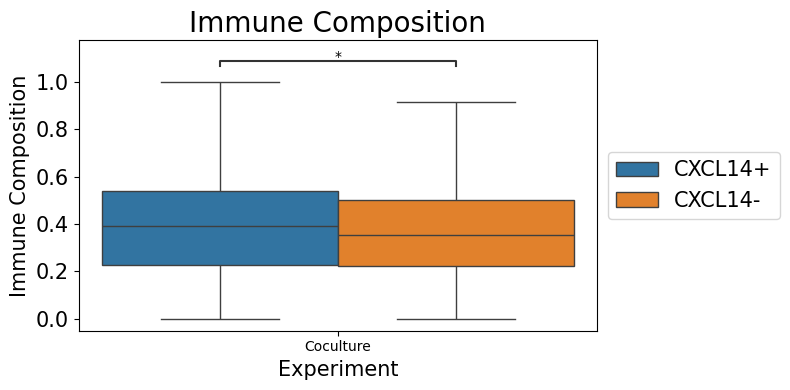

In [287]:
c = stats_df['Experiment'].unique()
hue_data = 'Stromal_label'
x_data = 'Experiment'
y_data = 'Immune Composition'
hue_order_data = ['CXCL14+', 'CXCL14-']
plt.figure(figsize=(8, 4))
plt.title('Immune Composition', fontsize=20)

box_pairs = [(('Coculture','CXCL14+'), ('Coculture','CXCL14-'))]

g = sns.boxplot(data=stats_df, x=x_data, y=y_data, hue=hue_data, hue_order=hue_order_data, showfliers=False)

# add_stat_annotation(g, data=ro60_stats_df, x=x, y=y, hue=hue, box_pairs=box_pairs, test='Mann-Whitney', loc='outside')

annot = Annotator(g, box_pairs, data=stats_df, x=x_data, y=y_data, hue=hue_data, hue_order=hue_order_data, correct='bonferroni')
annot.configure(test='Mann-Whitney', loc='inside', text_offset=-2, line_offset=-5)
annot.apply_and_annotate()

# g.set_xticklabels(label_names[:10], fontsize=15, rotation=90)
g.set_xlabel(x_data, fontsize=15)
g.set_ylabel(y_data, fontsize=15)
g.set_yticklabels(g.get_yticklabels(), fontsize=15)
g.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=15)
# plt.ylim(-2, 4)
plt.tight_layout()
# plt.savefig(r'..\figures\ro60 SSA+ v SSA-_x-axis_name.png', dpi=300)
plt.show()
plt.close()

## Xenium composition v. cxcl14

In [32]:
xenium_composition = pd.read_csv(r'Y:\coskun-lab\Zhou\12_MSG\nanostring_xenium_comp\results\graph_classification_v5\xenium\xenium_cell_type_composition_stromal_neighborhood.csv',index_col=0)

In [33]:
immune_cells = ['B-cell', 'CD4 T-cell', 'CD8 T-cell', 'Macrophage', 'Mast cell', 'Plasma cell']

In [34]:
annotation_dir = r'Y:\coskun-lab\Zhou\12_MSG\nanostring_xenium_comp\results\graph_classification_v5\xenium'
fns = ['xenium_83a', 'xenium_83b',
       'xenium_84a', 'xenium_84b',
       'xenium_174c', 'xenium_174d',
       'xenium_7202c', 'xenium_7202d']

annotations_tissue = {}
for fn in tqdm(fns):
    df = pd.read_csv(os.path.join(annotation_dir, f'{fn}_spatial_annotation_filtered.csv'))
    df.index = df['cell_id'].tolist()
    annotations_tissue[fn.split('_')[-1]] = df

exp_tissue = {}
annotation_dir = r'Y:\coskun-lab\Zhou\12_MSG\nanostring_xenium_comp\results\cell_type_annotation\v4'
for fn in tqdm(fns):
    adata = sc.read_h5ad(os.path.join(annotation_dir, 'adata_'+fn.split('_')[-1]+'.h5ad'))
    df = pd.DataFrame(adata.raw.X, index=adata.obs_names, columns=adata.var_names)
    exp_tissue[fn.split('_')[-1]] = df

idx_tissue = {}
annotation_dir = r'Y:\coskun-lab\Zhou\12_MSG\nanostring_xenium_comp\results\graph_classification_v5\xenium'
for fn in tqdm(fns):
    temp = fn.split('_')[-1]
    idx_tissue[fn.split('_')[-1]] = pd.read_pickle(os.path.join(annotation_dir, f'sub_graphs_{temp}_cell_index.pkl'))


100%|██████████| 8/8 [00:00<00:00, 35.37it/s]


In [35]:
for k in annotations_tissue:
    exp_tissue[k] = exp_tissue[k].loc[annotations_tissue[k].index.tolist()]

In [36]:
for k in annotations_tissue:
    try:
        assert(annotations_tissue[k].index.tolist() == exp_tissue[k].index.tolist())
    except AssertionError as e:
        print(f'tissue {k}')

In [37]:
cxcl14_labels = []
for k in annotations_tissue:
    stromal_cxcl14 = exp_tissue[k].iloc[idx_tissue[k]]['CXCL14']
    stromal_cxcl14_thre = threshold_triangle(stromal_cxcl14.to_numpy())
    stromal_cxcl14_label = (stromal_cxcl14 > stromal_cxcl14_thre).tolist()
    temp = ['CXCL14+' if item else 'CXCL14-' for item in stromal_cxcl14_label]
    cxcl14_labels.extend(temp)

In [38]:
immune_composition = xenium_composition[['B-cell', 'CD4 T-cell', 'CD8 T-cell', 'Dendritic cell', 'Macrophage', 'Mast cell', 'Plasma cell']].sum(axis=1)

In [39]:
stats_df.head()

,Stromal_label,Immune Composition,Experiment
0,CXCL14-,0.533333,Coculture
1,CXCL14-,0.615385,Coculture
2,CXCL14-,0.384615,Coculture
3,CXCL14-,0.384615,Coculture
4,CXCL14-,0.466667,Coculture


In [40]:
xenium_stats = {'Stromal_label':cxcl14_labels, 'Immune Composition':immune_composition, 'Experiment':['Xenium']*len(xenium_composition)}

In [41]:
xenium_stats = pd.DataFrame(xenium_stats)

## merfish composition v. cxcl14

In [42]:
merfish_composition = pd.read_csv(r"Y:\coskun-lab\Zhou\12_MSG\MERSCOPE\20251229_msg-1_140gene\results\stromal_neighborhoods\cell_composition.csv",index_col=0)

In [43]:
annotation_dir = r'Y:\coskun-lab\Zhou\12_MSG\MERSCOPE\20251229_msg-1_140gene\results'
fns = ['R1_7289', 'R2_7295', 'R3_7320', 'R8_159', 'R9_163']

annotations_tissue = {}
for fn in tqdm(fns):
    df = pd.read_csv(os.path.join(annotation_dir, f'202512291513_20251230msg1p140_VMSC11512_region_{fn}_annotated_filtered.csv'))
    df.index = df['cell'].astype(str).tolist()
    annotations_tissue[fn] = df

exp_tissue = {}
for fn in tqdm(fns):
    adata = sc.read_h5ad(os.path.join(annotation_dir, f'202512291513_20251230msg1p140_VMSC11512_region_{fn}_annotated.h5ad'))
    df = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
    exp_tissue[fn] = df

idx_tissue = {}
annotation_dir = r'Y:\coskun-lab\Zhou\12_MSG\MERSCOPE\20251229_msg-1_140gene\results\stromal_neighborhoods'
for fn in tqdm(fns):
    temp = pd.read_pickle(os.path.join(annotation_dir, f'sub_graphs_{fn}_cell_index.pkl'))
    idx_tissue[fn] = temp

100%|██████████| 5/5 [00:00<00:00, 25.51it/s]


In [44]:
for k in annotations_tissue:
    exp_tissue[k] = exp_tissue[k].loc[annotations_tissue[k].index.tolist()]

In [45]:
for k in annotations_tissue:
    try:
        assert(annotations_tissue[k].index.tolist() == exp_tissue[k].index.tolist())
    except AssertionError as e:
        print(f'tissue {k}')

In [46]:
cxcl14_labels = []
for k in annotations_tissue:
    stromal_cxcl14 = exp_tissue[k].iloc[idx_tissue[k]]['CXCL14']
    stromal_cxcl14_thre = threshold_triangle(stromal_cxcl14.to_numpy())
    stromal_cxcl14_label = (stromal_cxcl14 > stromal_cxcl14_thre).tolist()
    temp = ['CXCL14+' if item else 'CXCL14-' for item in stromal_cxcl14_label]
    cxcl14_labels.extend(temp)

In [47]:
merfish_composition.head()

,Acini,Ductal Epithelial,B-cell,Stromal,T-cell,Plasma cell,Endothelial cell,Pericytes,Macrophage,Mast cell,Myoepithelial,Dendritic cell
0,0.750000,0.000000,0.000000,0.062500,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.187500,0.0
1,0.500000,0.000000,0.222222,0.166667,0.000000,0.0,0.055556,0.0,0.000000,0.0,0.055556,0.0
2,0.444444,0.000000,0.222222,0.166667,0.000000,0.0,0.055556,0.0,0.000000,0.0,0.111111,0.0
3,0.210526,0.157895,0.157895,0.210526,0.052632,0.0,0.000000,0.0,0.105263,0.0,0.105263,0.0
4,0.166667,0.222222,0.166667,0.222222,0.055556,0.0,0.055556,0.0,0.055556,0.0,0.055556,0.0


In [48]:
immune_composition = merfish_composition[['B-cell', 'T-cell', 'Plasma cell', 'Macrophage', 'Mast cell', 'Dendritic cell']].sum(axis=1)

In [49]:
merfish_stats = {'Stromal_label':cxcl14_labels, 'Immune Composition':immune_composition, 'Experiment':['MERFISH']*len(merfish_composition)}

In [50]:
merfish_stats = pd.DataFrame(merfish_stats)

## combined stats

In [288]:
stats = pd.concat([stats_df, xenium_stats, merfish_stats])

In [289]:
stats

,Stromal_label,Immune Composition,Experiment
0,CXCL14-,0.533333,Coculture
1,CXCL14-,0.615385,Coculture
2,CXCL14-,0.615385,Coculture
3,CXCL14-,0.615385,Coculture
4,CXCL14-,0.666667,Coculture
...,...,...,...
9603,CXCL14+,0.500000,MERFISH
9604,CXCL14+,0.500000,MERFISH
9605,CXCL14+,0.111111,MERFISH
9606,CXCL14+,0.400000,MERFISH


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Xenium_CXCL14+ vs. Xenium_CXCL14-: Mann-Whitney-Wilcoxon test two-sided, P_val:9.696e-209 U_stat=1.645e+08
Coculture_CXCL14+ vs. Coculture_CXCL14-: Mann-Whitney-Wilcoxon test two-sided, P_val:1.001e-02 U_stat=2.765e+06
MERFISH_CXCL14+ vs. MERFISH_CXCL14-: Mann-Whitney-Wilcoxon test two-sided, P_val:1.013e-22 U_stat=6.282e+06


C:\Users\zfang38\AppData\Local\Temp\ipykernel_187040\2379170499.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_yticklabels(g.get_yticklabels(), fontsize=15)
C:\Users\zfang38\AppData\Local\Temp\ipykernel_187040\2379170499.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), fontsize=15, rotation=45)


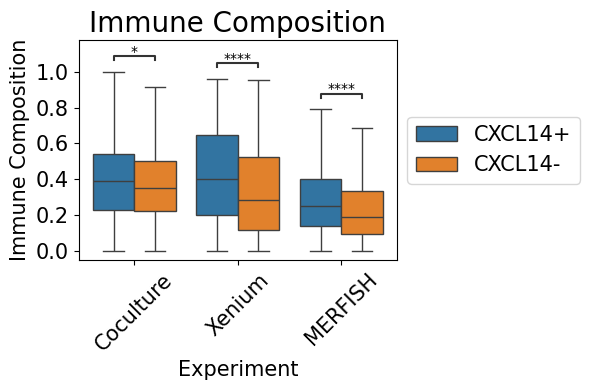

In [290]:
c = stats['Experiment'].unique()
hue_data = 'Stromal_label'
x_data = 'Experiment'
y_data = 'Immune Composition'
hue_order_data = ['CXCL14+', 'CXCL14-']
plt.figure(figsize=(6, 4))
plt.title('Immune Composition', fontsize=20)

box_pairs = [((experiment,'CXCL14+'), (experiment,'CXCL14-')) for experiment in c]

g = sns.boxplot(data=stats, x=x_data, y=y_data, hue=hue_data, hue_order=hue_order_data, showfliers=False)

# add_stat_annotation(g, data=ro60_stats_df, x=x, y=y, hue=hue, box_pairs=box_pairs, test='Mann-Whitney', loc='outside')

annot = Annotator(g, box_pairs, data=stats, x=x_data, y=y_data, hue=hue_data, hue_order=hue_order_data, correct='bonferroni')
annot.configure(test='Mann-Whitney', loc='inside', text_offset=-2, line_offset=-5)
annot.apply_and_annotate()

# g.set_xticklabels(label_names[:10], fontsize=15, rotation=90)
g.set_xlabel(x_data, fontsize=15)
g.set_ylabel(y_data, fontsize=15)
g.set_yticklabels(g.get_yticklabels(), fontsize=15)
g.set_xticklabels(g.get_xticklabels(), fontsize=15, rotation=45)
g.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=15)
# plt.ylim(-2, 4)
plt.tight_layout()
plt.savefig(r'..\figures\cxcl14+ stromal immune population.png', dpi=300)
plt.show()
plt.close()